In [1]:
import os
import ast
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 10})
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score
import torch
# Importing neuroimaging package(s)
import pydicom

In [2]:
import sys
sys.path.append('../src/')

%load_ext autoreload
%autoreload 2
# Importing our custom module(s)
import datasets
import models

In [3]:
dicom_dir = "/cluster/tufts/hugheslab/datasets/RSNA_PE"
labels_df = pd.read_csv(f"{dicom_dir}/labels.csv")
columns = ["pe_present_on_image", "path", "instance_number"]
labels_df[columns] = labels_df[columns].apply(lambda col: col.map(ast.literal_eval))
print(labels_df.shape)
labels_df.head()


(7279, 19)


,StudyInstanceUID,SeriesInstanceUID,SOPInstanceUID,pe_present_on_image,negative_exam_for_pe,qa_motion,qa_contrast,flow_artifact,rv_lv_ratio_gte_1,rv_lv_ratio_lt_1,leftsided_pe,chronic_pe,true_filling_defect_not_pe,rightsided_pe,acute_and_chronic_pe,central_pe,indeterminate,path,instance_number
0,0003b3d648eb,d2b2960c2bbf,"['14605bcc564c', 'd0849d3b6507', '18928b724b69...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",[/cluster/tufts/hugheslab/datasets/RSNA_PE/tra...,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
1,000f7f114264,9f7378c3b2ab,"['f703ce2bf7fb', '9b9ae16735d4', '0e7f2da710af...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",[/cluster/tufts/hugheslab/datasets/RSNA_PE/tra...,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
2,00102474a2db,c1a6d49ce580,"['e14dda12daca', 'd6c3488d6ecb', '1c3c4ac47230...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",[/cluster/tufts/hugheslab/datasets/RSNA_PE/tra...,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
3,0038fd5f09f5,0f0fb8cd3ee9,"['b1c5594efc22', '4deefe15ec0b', 'd996098c50cf...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",[/cluster/tufts/hugheslab/datasets/RSNA_PE/tra...,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
4,0045f113e031,454c8fdfb649,"['7ad80b1522f0', 'd36a05e0b6cd', '81

In [4]:
numpy_dir = "/cluster/tufts/hugheslab/datasets/RSNA_PE_numpy"
labels_df["path"] = labels_df["StudyInstanceUID"].apply(lambda study_id: f"{numpy_dir}/{study_id}.npz")
labels_df["PE"] = labels_df.apply(lambda row: float(any(row.pe_present_on_image)), axis=1)
#labels_df.to_csv(f"{numpy_dir}/labels.csv", index=False)
print(labels_df.shape)
labels_df.head()

(7279, 20)


,StudyInstanceUID,SeriesInstanceUID,SOPInstanceUID,pe_present_on_image,negative_exam_for_pe,qa_motion,qa_contrast,flow_artifact,rv_lv_ratio_gte_1,rv_lv_ratio_lt_1,leftsided_pe,chronic_pe,true_filling_defect_not_pe,rightsided_pe,acute_and_chronic_pe,central_pe,indeterminate,path,instance_number,PE
0,0003b3d648eb,d2b2960c2bbf,"['14605bcc564c', 'd0849d3b6507', '18928b724b69...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",/cluster/tufts/hugheslab/datasets/RSNA_PE_nump...,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",0.0
1,000f7f114264,9f7378c3b2ab,"['f703ce2bf7fb', '9b9ae16735d4', '0e7f2da710af...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",/cluster/tufts/hugheslab/datasets/RSNA_PE_nump...,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",0.0
2,00102474a2db,c1a6d49ce580,"['e14dda12daca', 'd6c3488d6ecb', '1c3c4ac47230...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",/cluster/tufts/hugheslab/datasets/RSNA_PE_nump...,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",0.0
3,0038fd5f09f5,0f0fb8cd3ee9,"['b1c5594efc22', '4deefe15ec0b', 'd996098c50cf...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",/cluster/tufts/hugheslab/datasets/RSNA_PE_nump...,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",0.0
4,0045f113e031,454c8fdfb649,"['7ad80b1522f0', 

In [12]:
num_lesions = np.zeros(len(labels_df))
lesion_lengths = []

for row_index, row in labels_df.iterrows():
    
    instance_labels = row["pe_present_on_image"]
    patience = 3
    
    counter = 0
    last_one = False
    k = patience
    
    for i in range(len(instance_labels)):

        if instance_labels[i] == 1.0:

            counter += 1
            last_one = True

            if k != patience:
                counter += patience - k

            k = patience

        else:  

            if last_one:

                if k > 0:
                    k -= 1
                else:
                    num_lesions[row_index] += 1
                    lesion_lengths.append(counter/len(instance_labels))
                    counter = 0
                    last_one = False
                    k = patience

    if counter > 0:
        num_lesions[row_index] += 1
        lesion_lengths.append(counter/len(instance_labels))
        
print(f"mean: {np.mean(lesion_lengths)}")
print(f"median: {np.median(lesion_lengths)}")


mean: 0.11945043786557955
median: 0.06276150627615062


In [13]:
print(f"{np.mean(lesion_lengths):.3f}")
print(f"{np.min(lesion_lengths):.3f}")
for q in np.quantile(lesion_lengths, [0.05, 0.25, 0.50, 0.75, 0.95]):
    print(f"{q:.3f}")
print(f"{np.max(lesion_lengths):.3f}")


0.119
0.002
0.006
0.027
0.063
0.174
0.401
0.870


In [10]:
np.unique(num_lesions, return_counts=True)

(array([0., 1., 2., 3., 4., 5., 6., 7.]),
 array([5068, 1437,  497,  185,   65,   16,    7,    4]))

In [ ]:
# labels_df = pd.read_csv(f"{dicom_dir}/labels.csv")
# columns = ["instance_number", "pe_present_on_image"]
# labels_df[columns] = labels_df[columns].apply(lambda col: col.map(ast.literal_eval))
# print(labels_df.shape)
# labels_df.head()


(69-348)


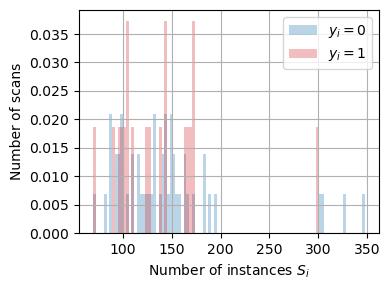

In [6]:
labels_df["PE"] = labels_df.apply(lambda row: float(any(row.pe_present_on_image)), axis=1)
lengths = labels_df.apply(lambda row: len(row.pe_present_on_image), axis=1)
print(f"({lengths.min()}-{lengths.max()})")

fig, ax = plt.subplots(1, 1, figsize=(4, 3))

ax.hist(lengths[labels_df.PE == 0.0], alpha=0.3, bins=np.linspace(lengths.min(), lengths.max(), 100), color="#1F77B4", density=True, label=r"$y_i=0$")
ax.hist(lengths[labels_df.PE == 1.0], alpha=0.3, bins=np.linspace(lengths.min(), lengths.max(), 100), color="#D62728", density=True, label=r"$y_i=1$")
ax.set_xlabel(r"Number of instances $S_i$")
ax.set_ylabel("Number of scans")
ax.legend()
ax.grid()

fig.tight_layout()

plt.show()

mean: 0.46840850403773066, std: 0.12070630077059218


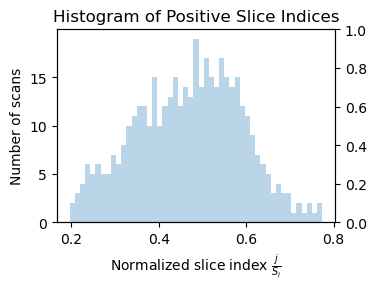

In [7]:
def normal_pdf(x, mu=0.0, sigma=1.0):
    norm_const = 1 / np.sqrt(2.0 * np.pi * sigma**2)
    exp_quad_term = np.exp(-0.5 * ((x - mu) / sigma) ** 2)
    return norm_const * exp_quad_term

series = labels_df.apply(lambda row: [j / len(row.pe_present_on_image) for j, y_ij in enumerate(row.pe_present_on_image) if y_ij == 1.0], axis=1)
values = [item for sublist in series for item in sublist]
mean, std = np.mean(values), np.std(values)
print(f"mean: {mean}, std: {std}")

fig, ax1 = plt.subplots(1, 1, figsize=(4, 3))

ax1.hist(values, alpha=0.3, bins=np.linspace(start=min(values), stop=max(values), num=50), color="#1F77B4")
ax2 = ax1.twinx()
x = np.linspace(start=0, stop=1, num=1_000)
#ax2.plot(x, normal_pdf(x, mean, std), color="#000000")
ax1.set_title("Histogram of Positive Slice Indices")
ax1.set_xlabel(r"Normalized slice index $\frac{j}{S_i}$")
ax1.set_ylabel("Number of scans")

fig.tight_layout()
plt.show()


In [6]:
merged_df = data_df.merge(instance_level_labels_df, on=["patient_id", "series_id", "instance_number"], how="left", indicator=True)
merged_df["instance_label"] = merged_df.apply(lambda row: 0.0 if row._merge == "left_only" else 1.0, axis=1)
print(merged_df.shape)
merged_df.head()


(1500653, 7)


,patient_id,series_id,instance_number,path,injury_name,_merge,instance_label
0,10004,21057,1000,/cluster/tufts/hugheslab/datasets/RSNA_AT/trai...,NaN,left_only,0.0
1,10004,21057,1001,/cluster/tufts/hugheslab/datasets/RSNA_AT/trai...,NaN,left_only,0.0
2,10004,21057,1002,/cluster/tufts/hugheslab/datasets/RSNA_AT/trai...,NaN,left_only,0.0
3,10004,21057,1003,/cluster/tufts/hugheslab/datasets/RSNA_AT/trai...,NaN,left_only,0.0
4,10004,21057,1004,/cluster/tufts/hugheslab/datasets/RSNA_AT/trai...,NaN,left_only,0.0


In [7]:
merged_df = merged_df.sort_values(by=["patient_id", "series_id", "instance_number"], ascending=[True, True, True])
labels_df = merged_df.groupby(["patient_id", "series_id"]).agg(list).reset_index()
print(labels_df.shape)
labels_df.head()


(4711, 7)


,patient_id,series_id,instance_number,path,injury_name,_merge,instance_label
0,19,14374,"[229, 230, 231, 232, 233, 234, 235, 236, 237, ...",[/cluster/tufts/hugheslab/datasets/RSNA_AT/tra...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[left_only, left_only, left_only, left_only, l...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,26,18881,"[53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 6...",[/cluster/tufts/hugheslab/datasets/RSNA_AT/tra...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[left_only, left_only, left_only, left_only, l...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,26,41997,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",[/cluster/tufts/hugheslab/datasets/RSNA_AT/tra...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[left_only, left_only, left_only, left_only, l...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,33,55570,"[19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 3...",[/cluster/tufts/hugheslab/datasets/RSNA_AT/tra...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[left_only, left_only, left_only, left_only, l...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,43,24055,"[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 1...",[/cluster/tufts/hugheslab/datasets/RSNA_AT/tra...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[left_only, left_only, left_only, left_only, l...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [9]:
numpy_dir = "/cluster/tufts/hugheslab/datasets/RSNA_AT_numpy"
labels_df["AT"] = labels_df.apply(lambda row: float(any(row.instance_label)), axis=1)
labels_df["path"] = labels_df["series_id"].apply(lambda series_id: f"{numpy_dir}/{series_id}.npz")
#labels_df.to_csv(f"{numpy_dir}/labels.csv", index=False)
print(labels_df.shape)
labels_df.head()


(4711, 8)


,patient_id,series_id,instance_number,path,injury_name,_merge,instance_label,AT
0,19,14374,"[229, 230, 231, 232, 233, 234, 235, 236, 237, ...",/cluster/tufts/hugheslab/datasets/RSNA_AT_nump...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[left_only, left_only, left_only, left_only, l...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0
1,26,18881,"[53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 6...",/cluster/tufts/hugheslab/datasets/RSNA_AT_nump...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[left_only, left_only, left_only, left_only, l...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0
2,26,41997,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",/cluster/tufts/hugheslab/datasets/RSNA_AT_nump...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[left_only, left_only, left_only, left_only, l...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0
3,33,55570,"[19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 3...",/cluster/tufts/hugheslab/datasets/RSNA_AT_nump...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[left_only, left_only, left_only, left_only, l...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1.0
4,43,24055,"[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 1...",/cluster/tufts/hugheslab/datasets/RSNA_AT_nump...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[left_only, left_only, left_only, left_only, l...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1.0


In [10]:
# for row_index, row in grouped_df.iterrows():
#     scan = []
#     for path in row.path:
#         ds = pydicom.dcmread(path)
#         pixel_array = ds.pixel_array.astype(np.float32)
#         slope = float(getattr(ds, "RescaleSlope", 1))
#         intercept = float(getattr(ds, "RescaleIntercept", 0))
#         rescaled = pixel_array * slope + intercept
#         scan.append(rescaled)
#     print(np.expand_dims(np.stack(scan, axis=-1), axis=0).shape)
#     np.savez(f"{numpy_dir}/{row.series_id}.npz", np.expand_dims(np.stack(scan, axis=-1), axis=0))

In [22]:
labels_df = pd.read_csv(f"{numpy_dir}/labels.csv")
columns = ["instance_number", "instance_label"]
labels_df[columns] = labels_df[columns].apply(lambda col: col.map(ast.literal_eval))
print(labels_df.shape)
labels_df.head()


(4711, 8)


,patient_id,series_id,instance_number,path,injury_name,_merge,instance_label,AT
0,19,14374,"[229, 230, 231, 232, 233, 234, 235, 236, 237, ...",/cluster/tufts/hugheslab/datasets/RSNA_AT_nump...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","['left_only', 'left_only', 'left_only', 'left_...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0
1,26,18881,"[53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 6...",/cluster/tufts/hugheslab/datasets/RSNA_AT_nump...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","['left_only', 'left_only', 'left_only', 'left_...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0
2,26,41997,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",/cluster/tufts/hugheslab/datasets/RSNA_AT_nump...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","['left_only', 'left_only', 'left_only', 'left_...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0
3,33,55570,"[19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 3...",/cluster/tufts/hugheslab/datasets/RSNA_AT_nump...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","['left_only', 'left_only', 'left_only', 'left_...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1.0
4,43,24055,"[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 1...",/cluster/tufts/hugheslab/datasets/RSNA_AT_nump...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","['left_only', 'left_only', 'left_only', 'left_...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1.0


(512, 512)


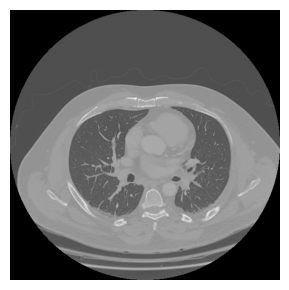

In [15]:
ds = pydicom.dcmread(f"{dicom_dir}/train_images/19/14374/229.dcm")
print(ds.pixel_array.shape)

fig, ax = plt.subplots(1, 1, figsize=(4, 3))

ax.imshow(ds.pixel_array, cmap="gray")
ax.axis("off")

fig.tight_layout()

plt.show()

In [3]:
################################################################################
def print_job(
    alpha, batch_size, criterion, dataset_dir, epochs, embedding_level, 
    experiments_dir, lr, pooling, save, seed, weight_decay
):
    
    model_name = f"alpha={alpha}_criterion={criterion}_lr={lr}_pooling={pooling}_seed={seed}"
    
    if os.path.exists(f"{experiments_dir}/{model_name}.csv"):
        temp_df = pd.read_csv(f"{experiments_dir}/{model_name}.csv")
        if temp_df.shape[0] == epochs:
            return
        
    embedding_level = "--embedding_level " if embedding_level else ""
    save = "--save " if save else ""
    
    command = (
        f"python ../src/oasis-3.py "
        f"--alpha={alpha} "
        f"--batch_size={batch_size} "
        f"--criterion=\"{criterion}\" "
        f"--dataset_dir=\"{dataset_dir}\" "
        f"--epochs={epochs} "
        f"{embedding_level}"
        f"--experiments_dir=\"{experiments_dir}\" "
        f"--lr={lr} "
        f"--model_name=\"{model_name}\" "
        f"--pooling=\"{pooling}\" "
        f"{save}"
        f"--seed={seed} "
        f"--weight_decay={weight_decay}"
    )
    
    print(f"    \'{command}\'")

In [4]:
alphas = [1.0, 0.1, 0.01, 0.001, 0.0001, 1e-05, 1e-06, 0.0]
alphas = [1e-05]
beta = 0.0
batch_size = 64
criterions = ["GuidedL1"]
dataset_dir = "/cluster/tufts/hugheslab/datasets/encoded_RSNA_PE/ViT_B_16"
epochs = 1000
embedding_level = True
experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_PE_embedding_level=True" 
experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_PE_beta=1.0_embedding_level=True" 
experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_PE_beta2=1.0_embedding_level=True" 
#experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_PE_beta=1.0_embedding_level=True_multi_head=False" 
lrs = [0.1, 0.01, 0.001, 0.0001]
poolings = ["Max", "Mean", "ABMIL", "TransMIL", "SmAP"]
poolings = ["SmTAP"]
poolings = ["TransMIL"]
save = True
seeds = [1001, 2001, 3001]
weight_decay = 0.0

for alpha, criterion, lr, pooling, seed in itertools.product(alphas, criterions, lrs, poolings, seeds):
    
    temp_dataset_dir = f"{dataset_dir}/seed={seed}"

    print_job(alpha, batch_size, criterion, temp_dataset_dir, epochs, embedding_level, 
              experiments_dir, lr, pooling, save, seed, weight_decay)


    'python ../src/oasis-3.py --alpha=1e-05 --batch_size=64 --criterion="GuidedL1" --dataset_dir="/cluster/tufts/hugheslab/datasets/encoded_RSNA_PE/ViT_B_16/seed=1001" --epochs=1000 --embedding_level --experiments_dir="/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_PE_beta2=1.0_embedding_level=True" --lr=0.1 --model_name="alpha=1e-05_criterion=GuidedL1_lr=0.1_pooling=TransMIL_seed=1001" --pooling="TransMIL" --save --seed=1001 --weight_decay=0.0'
    'python ../src/oasis-3.py --alpha=1e-05 --batch_size=64 --criterion="GuidedL1" --dataset_dir="/cluster/tufts/hugheslab/datasets/encoded_RSNA_PE/ViT_B_16/seed=2001" --epochs=1000 --embedding_level --experiments_dir="/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_PE_beta2=1.0_embedding_level=True" --lr=0.1 --model_name="alpha=1e-05_criterion=GuidedL1_lr=0.1_pooling=TransMIL_seed=2001" --pooling="TransMIL" --save --seed=2001 --weight_decay=0.0'
    'python ../src/oasis-3.py --alpha=1e-05 --batch_size=64 --criterion="Gui

In [3]:
alphas = [1.0, 0.1, 0.01, 0.001, 0.0001, 1e-05, 1e-06, 0.0]
beta = 0.0
batch_size = 64
criterions = ["GuidedL1"]
dataset_dir = "/cluster/tufts/hugheslab/datasets/encoded_RSNA_PE/ViT_B_16"
epochs = 1000
embedding_level = True
#experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_PE_embedding_level=True" 
#experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_PE_beta=1.0_embedding_level=True" 
experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_PE_beta2=1.0_embedding_level=True" 
#experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_PE_beta=1.0_embedding_level=True_multi_head=False" 
#experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_PE_best_possible_instance-level" 
#experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_PE_best_possible_bag-level" 
lrs = [0.1, 0.01, 0.001, 0.0001]
poolings = ["TransMIL"]
save = True
seeds = [1001, 2001, 3001]
weight_decay = 0.0

columns = ["model_name", "seed", "test_auroc", "test_auprc", "test_bal_acc", "test_loss", "test_nll", "train_auroc", "train_auprc", "train_bal_acc", "train_loss", "train_nll", "val_auroc", "val_auprc", "val_bal_acc", "val_loss", "val_nll"]
df = pd.DataFrame(columns=columns)

for alpha, criterion, lr, pooling, seed in itertools.product(alphas, criterions, lrs, poolings, seeds):
    
    model_name = f"alpha={alpha}_criterion={criterion}_lr={lr}_pooling={pooling}_seed={seed}"
    #model_name = f"alpha={alpha}_criterion={criterion}_lr={lr}_seed={seed}"
    
    if os.path.exists(f"{experiments_dir}/{model_name}.csv"):
        temp_df = pd.read_csv(f"{experiments_dir}/{model_name}.csv")
        if len(temp_df[temp_df.train_auroc > temp_df.val_auroc]):
            index = temp_df[temp_df.train_auroc > temp_df.val_auroc].val_auroc.idxmax()
            row = [model_name, seed, temp_df.test_auroc.values[index], temp_df.test_auprc.values[index], temp_df.test_bal_acc.values[index], temp_df.test_loss.values[index], temp_df.test_nll.values[index], temp_df.train_auroc.values[index], temp_df.train_auprc.values[index], temp_df.train_bal_acc.values[index], temp_df.train_loss.values[index], temp_df.train_nll.values[index], temp_df.val_auroc.values[index], temp_df.val_auprc.values[index], temp_df.val_bal_acc.values[index], temp_df.val_loss.values[index], temp_df.val_nll.values[index]]
            df.loc[len(df)] = row
        
indices = df.groupby(["seed"])["val_auroc"].idxmax()
df = df.loc[indices].reset_index(drop=True)

df.head()

,model_name,seed,test_auroc,test_auprc,test_bal_acc,test_loss,test_nll,train_auroc,train_auprc,train_bal_acc,train_loss,train_nll,val_auroc,val_auprc,val_bal_acc,val_loss,val_nll
0,alpha=1e-05_criterion=GuidedL1_lr=0.001_poolin...,1001,0.690371,0.478722,0.566655,1.119201,0.570492,0.754498,0.590961,0.629319,1.070343,0.522019,0.666192,0.458512,0.580797,1.131268,0.583385
1,alpha=1e-05_criterion=GuidedL1_lr=0.01_pooling...,2001,0.663110,0.447872,0.525266,1.150149,0.608928,0.706446,0.523579,0.606070,1.100037,0.559239,0.680747,0.492791,0.534603,1.135226,0.593709
2,alpha=1e-05_criterion=GuidedL1_lr=0.01_pooling...,3001,0.643880,0.441819,0.540798,1.178772,0.638001,0.718024,0.519455,0.605403,1.092667,0.551331,0.685024,0.461699,0.555004,1.138571,0.595859


In [4]:
print(f"${df.test_auroc.mean():.3f}${{\\tiny$\pm {df.test_auroc.std():.3f}$}}")
print(f"${df.test_auprc.mean():.3f}${{\\tiny$\pm {df.test_auprc.std():.3f}$}}")


$0.666${\tiny$\pm 0.023$}
$0.456${\tiny$\pm 0.020$}


In [5]:
df.model_name.values

array(['alpha=1e-05_criterion=GuidedL1_lr=0.001_pooling=TransMIL_seed=1001',
       'alpha=1e-05_criterion=GuidedL1_lr=0.01_pooling=TransMIL_seed=2001',
       'alpha=1e-05_criterion=GuidedL1_lr=0.01_pooling=TransMIL_seed=3001'],
      dtype=object)

In [6]:
numpy_dir = "/cluster/tufts/hugheslab/datasets/RSNA_PE_numpy"
labels_df = pd.read_csv(f"{numpy_dir}/labels.csv")
columns = ["pe_present_on_image", "instance_number"]
labels_df[columns] = labels_df[columns].apply(lambda col: col.map(ast.literal_eval))
print(labels_df.shape)
labels_df.head()


(7279, 20)


,StudyInstanceUID,SeriesInstanceUID,SOPInstanceUID,pe_present_on_image,negative_exam_for_pe,qa_motion,qa_contrast,flow_artifact,rv_lv_ratio_gte_1,rv_lv_ratio_lt_1,leftsided_pe,chronic_pe,true_filling_defect_not_pe,rightsided_pe,acute_and_chronic_pe,central_pe,indeterminate,path,instance_number,PE
0,0003b3d648eb,d2b2960c2bbf,"['14605bcc564c', 'd0849d3b6507', '18928b724b69...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",/cluster/tufts/hugheslab/datasets/RSNA_PE_nump...,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",0.0
1,000f7f114264,9f7378c3b2ab,"['f703ce2bf7fb', '9b9ae16735d4', '0e7f2da710af...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",/cluster/tufts/hugheslab/datasets/RSNA_PE_nump...,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",0.0
2,00102474a2db,c1a6d49ce580,"['e14dda12daca', 'd6c3488d6ecb', '1c3c4ac47230...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",/cluster/tufts/hugheslab/datasets/RSNA_PE_nump...,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",0.0
3,0038fd5f09f5,0f0fb8cd3ee9,"['b1c5594efc22', '4deefe15ec0b', 'd996098c50cf...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",/cluster/tufts/hugheslab/datasets/RSNA_PE_nump...,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",0.0
4,0045f113e031,454c8fdfb649,"['7ad80b1522f0', 

In [13]:
seed = 3001

grouped_df = labels_df.groupby("StudyInstanceUID")["PE"].agg(lambda x: x.mode()[0]).reset_index()
ids, id_labels = grouped_df["StudyInstanceUID"], grouped_df["PE"]
train_and_val_ids, test_ids, train_and_val_id_labels, test_id_labels = train_test_split(ids, id_labels, test_size=1/6, random_state=seed, stratify=id_labels)
train_ids, val_ids = train_test_split(train_and_val_ids, test_size=1/5, random_state=seed, stratify=train_and_val_id_labels)

train_df = labels_df[labels_df["StudyInstanceUID"].isin(train_ids)]
val_df = labels_df[labels_df["StudyInstanceUID"].isin(val_ids)]
test_df = labels_df[labels_df["StudyInstanceUID"].isin(test_ids)]

dataset_dir = f"/cluster/tufts/hugheslab/datasets/encoded_RSNA_PE/ViT_B_16/seed={seed}"

train_data = torch.load(f"{dataset_dir}/train.pt", map_location=torch.device("cpu"))
val_data = torch.load(f"{dataset_dir}/val.pt", map_location=torch.device("cpu"))
test_data = torch.load(f"{dataset_dir}/test.pt", map_location=torch.device("cpu"))

train_dataset = datasets.MILTensorDataset(train_data["X"], train_data["lengths"], train_data["y"])
val_dataset = datasets.MILTensorDataset(val_data["X"], val_data["lengths"], val_data["y"])
test_dataset = datasets.MILTensorDataset(test_data["X"], test_data["lengths"], test_data["y"])


In [14]:
model = models.PoolClf(in_features=768, out_features=1, pooling="ABMIL")
model = models.PoolClf(in_features=768, out_features=1, pooling="TransMIL")
#model = models.PoolClf(in_features=768, out_features=1, pooling="SmAP")
#model = models.PoolClf(in_features=768, out_features=1, pooling="SmTAP")
#model = models.InstanceLevelClassifier(in_features=768, out_features=1, kernel_size=35)

experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_PE_embedding_level=True"
#experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_PE_beta=1.0_embedding_level=True"
experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_PE_beta2=1.0_embedding_level=True"
#experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_PE_beta=1.0_embedding_level=True_multi_head=False"
#experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_PE_best_possible_instance-level"

#model_name = "alpha=1e-05_criterion=L1_lr=0.01_pooling=ABMIL_seed=1001"
#model_name = "alpha=0.001_criterion=L1_lr=0.01_pooling=ABMIL_seed=2001"
#model_name = "alpha=0.001_criterion=L1_lr=0.01_pooling=ABMIL_seed=3001"
#model_name = "alpha=0.001_criterion=L1_lr=0.01_pooling=SmAP_seed=1001"
#model_name = "alpha=0.001_criterion=L1_lr=0.01_pooling=SmAP_seed=2001"
#model_name = "alpha=0.001_criterion=L1_lr=0.01_pooling=SmAP_seed=3001"
#model_name = "alpha=0.0_criterion=L1_lr=0.01_pooling=TransMIL_seed=1001"
#model_name = "alpha=1e-05_criterion=L1_lr=0.01_pooling=TransMIL_seed=2001"
#model_name = "alpha=1e-05_criterion=L1_lr=0.01_pooling=TransMIL_seed=3001"
#model_name = "alpha=0.001_criterion=GuidedL1_lr=0.01_pooling=ABMIL_seed=1001"
#model_name = "alpha=1e-05_criterion=GuidedL1_lr=0.01_pooling=ABMIL_seed=2001"
#model_name = "alpha=0.001_criterion=GuidedL1_lr=0.01_pooling=ABMIL_seed=3001"
#model_name = "alpha=1e-05_criterion=GuidedL1_lr=0.01_pooling=TransMIL_seed=1001"
#model_name = "alpha=1e-05_criterion=GuidedL1_lr=0.001_pooling=TransMIL_seed=2001"
#model_name = "alpha=1e-05_criterion=GuidedL1_lr=0.001_pooling=TransMIL_seed=3001"
#model_name = "alpha=1e-05_criterion=L1_lr=0.01_pooling=SmTAP_seed=1001"
#model_name = "alpha=1e-05_criterion=L1_lr=0.01_pooling=SmTAP_seed=2001"
#model_name = "alpha=1e-05_criterion=L1_lr=0.01_pooling=SmTAP_seed=3001"

model_name = "alpha=1e-05_criterion=GuidedL1_lr=0.001_pooling=TransMIL_seed=1001"
model_name = "alpha=1e-05_criterion=GuidedL1_lr=0.01_pooling=TransMIL_seed=2001"
model_name = "alpha=1e-05_criterion=GuidedL1_lr=0.01_pooling=TransMIL_seed=3001"


#model_name = "alpha=0.0_criterion=L1_lr=0.1_seed=1001"
#model_name = "alpha=0.0_criterion=L1_lr=0.1_seed=2001"
#model_name = "alpha=0.0_criterion=L1_lr=0.1_seed=3001"

checkpoint = torch.load(f"{experiments_dir}/{model_name}.pt", map_location=torch.device("cpu"))

model.load_state_dict(checkpoint)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)
model.to(device)

attn_corrs = []
aurocs = []
auprcs = []

with torch.no_grad():
    
    for i in range(len(test_dataset)):
        h_i, S_i, y_i = test_dataset[i]
        y_ij = test_data["lengths_y"][i]

        if y_i == 1.0:
            #x = torch.arange(start=1, end=S_i + 1)
            #a_i = utils.normal_pdf(x, mu=S_i / 2, sigma=1.0)
            #a_i = a_i / a_i.sum()
            #a_i = torch.stack([torch.sum(torch.argmax(h_i, dim=0, keepdim=True) == j) / h_i.shape[1] for j in range(S_i)]).unsqueeze(1)
            #a_i = np.ones_like(y_ij) / S_i
            _, a_i = model(h_i, (S_i,))
            a_i = torch.mean(a_i, dim=1).detach()
            attn_corrs.append(a_i[np.array(y_ij) == 1.0].sum())
            aurocs.append(roc_auc_score(y_ij, a_i))
            auprcs.append(average_precision_score(y_ij, a_i))


cpu


In [15]:
print(np.mean(attn_corrs))
print(np.mean(aurocs))
print(np.mean(auprcs))

0.31274426
0.8667021635959933
0.5200503485474972


In [16]:
guided2_transmil_aurocs = [0.8672416582980124, 0.8663815661424559, 0.8667021635959933]
guided2_transmil_auprcs = [0.5213738385328153, 0.5219343474553625, 0.5200503485474972]
print(f"${np.mean(guided2_transmil_aurocs):.3f}${{\\tiny$\pm {np.std(guided2_transmil_aurocs):.3f}$}}")
print(f"${np.mean(guided2_transmil_auprcs):.3f}${{\\tiny$\pm {np.std(guided2_transmil_auprcs):.3f}$}}")


$0.867${\tiny$\pm 0.000$}
$0.521${\tiny$\pm 0.001$}


In [19]:
smtap_aurocs = [0.6147427320644234, 0.6478572974408581, 0.7001687698146956]
smtap_auprcs = [0.2853470036566226, 0.31487626492564375, 0.3276808483966041]
print(f"${np.mean(smtap_aurocs):.3f}${{\\tiny$\pm {np.std(smtap_aurocs):.3f}$}}")
print(f"${np.mean(smtap_auprcs):.3f}${{\\tiny$\pm {np.std(smtap_auprcs):.3f}$}}")


$0.654${\tiny$\pm 0.035$}
$0.309${\tiny$\pm 0.018$}


In [35]:
guided_transmil_aurocs = [0.8718904978125729, 0.8691006172162217, 0.8671911195194995]
guided_transmil_auprcs = [0.5399102914371458, 0.5351636871547618, 0.5284642253033134]
print(f"${np.mean(guided_transmil_aurocs):.3f}${{\\tiny$\pm {np.std(guided_transmil_aurocs):.3f}$}}")
print(f"${np.mean(guided_transmil_auprcs):.3f}${{\\tiny$\pm {np.std(guided_transmil_auprcs):.3f}$}}")


$0.865${\tiny$\pm 0.002$}
$0.535${\tiny$\pm 0.005$}


In [13]:
transmil_aurocs = [0.5865695131779012, 0.4902988280170815, 0.6786811824275253]
transmil_auprcs = [0.26143156288507186, 0.19175259115710688, 0.3196473006961758]
print(f"${np.mean(transmil_aurocs):.3f}${{\\tiny$\pm {np.std(transmil_aurocs):.3f}$}}")
print(f"${np.mean(transmil_auprcs):.3f}${{\\tiny$\pm {np.std(transmil_auprcs):.3f}$}}")


$0.585${\tiny$\pm 0.077$}
$0.258${\tiny$\pm 0.052$}


In [31]:
guided_abmil_aurocs = [0.8718511928024866, 0.8671009180387269, 0.8588542619962045]
guided_abmil_auprcs = [0.5330725399973697, 0.5127277646401686, 0.5210248179501423]
print(f"${np.mean(guided_abmil_auprcs):.3f}${{\\tiny$\pm {np.std(guided_abmil_auprcs):.3f}$}}")


$0.522${\tiny$\pm 0.008$}


In [14]:
gaussian_attn_corr = [0.5092617072622768, 0.4588816378762005, 0.5018890098989865]
max_attn_corr = [0.16917557, 0.16971898, 0.16313797]
mean_attn_corr = [0.1887258651371717, 0.1897570410315229, 0.18689367001062096]
abmil_attn_corr = [0.24060695, 0.18975703, 0.18689366]
smap_attn_corr = [0.22695202, 0.28088018, 0.22916278]
best_attn_corr = [0.44294795, 0.43719226, 0.4457676]
print(f"${np.mean(max_attn_corr):.3f}${{\\tiny$\pm {np.std(max_attn_corr):.3f}$}}")


$0.167${\tiny$\pm 0.003$}


In [15]:
gaussian_aurocs = [0.7832979097120129, 0.7791184309684261, 0.7786170134477347]
max_aurocs = [0.4648374105814422, 0.4593296656759338, 0.457414765582023]
mean_aurocs = [0.5, 0.5, 0.5]
abmil_aurocs = [0.674868861721825, 0.47249927223722926, 0.525721810745831]
smap_aurocs = [0.6552181010610411, 0.7488858948674848, 0.6606683246544706]
best_aurocs = [0.8759533836532241, 0.8660686777328339, 0.8709366550958908]
print(f"${np.mean(max_aurocs):.3f}${{\\tiny$\pm {np.std(max_aurocs):.3f}$}}")


$0.461${\tiny$\pm 0.003$}


In [16]:
gaussian_auprcs = [0.4880391973202866, 0.46995777429489294, 0.4838127814271882]
max_auprcs = [0.18579186422055657, 0.18675054345700634, 0.18155056344058276]
mean_auprcs = [0.1887258651371717, 0.1897570410315229, 0.18689367001062096]
abmil_auprcs = [0.3173310225663945, 0.18697745311015285, 0.19588183894391478]
smap_auprcs = [0.31564624771381833, 0.3955919061034876, 0.3207543634254323]
best_auprcs = [0.5264707228262319, 0.5235872137940779, 0.5328207952550057]
print(f"${np.mean(max_auprcs):.3f}${{\\tiny$\pm {np.std(max_auprcs):.3f}$}}")


$0.185${\tiny$\pm 0.002$}
